# NB 07: Signal Integration & Strategy Report

**Objective**: Connect walk-forward PC2 signal to option structure entry/exit. Full conditioned strategy report with transaction costs.

**Signal Logic** (this notebook — D9-10 exploration):
- D9-D10 (steep skew) $\rightarrow$ Enter short-skew structure (PUT_RATIO_1x2 or PUT_BWB_SHORT_SKEW)
- D1-D8 $\rightarrow$ No position

Long-skew entry infrastructure (PUT_BACKSPREAD_2x1, PUT_BWB_LONG_SKEW) exists but is **not active** — insufficient OOS observations to validate. NB08 widens to the D7+ gate, validated empirically from Section 5 regime analysis here.

**Key Questions**:
- Does PC2 conditioning improve Sharpe over unconditional baseline?
- Does delta hedging add meaningful risk-adjusted improvement?
- Are transaction costs survivable at realistic 1×/2×/3× multiples?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime

from trade_data import (
    load_market_data, load_vol_features, build_trade_df,
    compute_delta_hedge_pnl, StrategyParams,
    PUT_RATIO_1x2, PUT_BWB_SHORT_SKEW, PUT_BACKSPREAD_2x1, PUT_BWB_LONG_SKEW,
)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PARENT_DIR = os.path.abspath('..')

## 1. Load Walk-Forward Signal & Trade Data

Walk-forward observations are monthly (see cell output for current count). Decile distribution is heavily skewed toward D9-D10 vs D1-D3: the signal spends significantly more time in "short skew" territory (steep skew, D9-10) than "long skew" (flat skew, D1-3). This confirms the asymmetry from NB 03 — equity skew is persistently steep.

In [2]:
# Load walk-forward PC2 results (month-end timing)
wf = pl.read_parquet(os.path.join(PARENT_DIR, 'data/walk_forward_results_month_end.parquet'))
print(f'Walk-forward results: {wf.height} observations')
print(f'Date range: {wf["date"].min()} to {wf["date"].max()}')
print(f'Decile distribution:')
print(wf.group_by('decile').len().sort('decile'))

Walk-forward results: 98 observations
Date range: 2018-02-28 to 2026-03-19
Decile distribution:
shape: (10, 2)
┌────────┬─────┐
│ decile ┆ len │
│ ---    ┆ --- │
│ i64    ┆ u32 │
╞════════╪═════╡
│ 1      ┆ 6   │
│ 2      ┆ 8   │
│ 3      ┆ 8   │
│ 4      ┆ 13  │
│ 5      ┆ 3   │
│ 6      ┆ 9   │
│ 7      ┆ 9   │
│ 8      ┆ 12  │
│ 9      ┆ 10  │
│ 10     ┆ 20  │
└────────┴─────┘


In [4]:
# Load market data and build trade_dfs
print('Loading market data...')
df_market = load_market_data().collect()
df_market = df_market.filter(pl.col('date') >= datetime.date(2016, 1, 1))
vol_features = load_vol_features()

# Build all 4 structures
STRUCTURES = {
    'short_ratio': PUT_RATIO_1x2,
    'short_bwb': PUT_BWB_SHORT_SKEW,
    'long_ratio': PUT_BACKSPREAD_2x1,
    'long_bwb': PUT_BWB_LONG_SKEW,
}

trade_dfs = {}
for name, structure in STRUCTURES.items():
    params = StrategyParams(structure=structure)
    tdf = build_trade_df(df_market, vol_features, params)
    trade_dfs[name] = tdf
    print(f'  {name}: {tdf.height:,} rows, {tdf["date"].n_unique()} dates')

print('Done.')

Loading market data...
  short_ratio: 4,990 rows, 2495 dates
  short_bwb: 7,479 rows, 2493 dates
  long_ratio: 4,990 rows, 2495 dates
  long_bwb: 7,479 rows, 2493 dates
Done.


In [5]:
def add_vega_scaling(trade_df: pl.DataFrame) -> pl.DataFrame:
    """Add vega normalization (100 abs vega at entry)."""
    df = (
        trade_df
        .sort('date', 'leg_label')
        .with_columns(
            pl.when(pl.col('position_action') == 'Open')
              .then(pl.col('date'))
              .otherwise(None)
              .forward_fill()
              .over('leg_label')
              .alias('roll_id')
        )
    )
    open_vega = (
        df.filter(pl.col('position_action') == 'Open')
        .group_by('roll_id')
        .agg(pl.col('pos_vega').abs().sum().alias('agg_abs_vega'))
    )
    df = (
        df.join(open_vega, on='roll_id', how='left')
        .with_columns((100.0 / pl.col('agg_abs_vega')).alias('vega_scale'))
        .with_columns((pl.col('pnl') * pl.col('vega_scale')).alias('scaled_pnl'))
    )
    return df

# Apply vega scaling
for name in trade_dfs:
    trade_dfs[name] = add_vega_scaling(trade_dfs[name])

def compute_sharpe(pnl: np.ndarray) -> float:
    m, s = np.mean(pnl), np.std(pnl)
    return (m / s * np.sqrt(252)) if s > 0 else 0.0

def max_drawdown(cum_pnl: np.ndarray) -> float:
    return float((cum_pnl - np.maximum.accumulate(cum_pnl)).min())

def compute_hedged_daily(trade_df: pl.DataFrame) -> pl.DataFrame:
    """Compute daily delta-hedged PnL from a vega-scaled trade_df.

    Scales pos_delta by vega_scale so hedge ratio is in vega-normalized space,
    then calls compute_delta_hedge_pnl().
    """
    scaled_df = trade_df.with_columns([
        (pl.col('scaled_pnl')).alias('pnl'),
        (pl.col('pos_delta') * pl.col('vega_scale')).alias('pos_delta'),
        (pl.col('pos_gamma') * pl.col('vega_scale')).alias('pos_gamma'),
        (pl.col('pos_theta') * pl.col('vega_scale')).alias('pos_theta'),
        (pl.col('pos_vega') * pl.col('vega_scale')).alias('pos_vega'),
    ])
    return compute_delta_hedge_pnl(scaled_df)

# Build hedged daily PnL for all structures
hedged_daily = {}
for name in trade_dfs:
    hedged_daily[name] = compute_hedged_daily(trade_dfs[name])
    print(f'  hedged {name}: {hedged_daily[name].height} daily rows')

  hedged short_ratio: 2486 daily rows
  hedged short_bwb: 2484 daily rows
  hedged long_ratio: 2486 daily rows
  hedged long_bwb: 2484 daily rows


## 2. Join PC2 Deciles to Trading Dates

Walk-forward rebalance dates are monthly. Between rebalance dates, forward-fill the most recent decile assignment to every trading date.

**Signal distribution** (1,974 trading dates, 2018-02-28 to 2026-02-02):
- **Short skew (D9-10)**: 626 days (31.7%) — active signal
- **Neutral (D1-8)**: 1,348 days (68.3%) — no position

Long-skew infrastructure (D1-3) exists but is **not activated** — gate is commented out (insufficient OOS observations). NB08 uses a wider D7+ gate validated empirically from the regime analysis in this notebook.

In [6]:
# Create daily signal from walk-forward deciles
# Forward-fill decile from rebalance dates to all trading dates
all_trading_dates = (
    trade_dfs['short_bwb']
    .select('date')
    .unique()
    .sort('date')
)

signal_df = (
    all_trading_dates
    .join(
        wf.select(['date', 'decile', 'pc2_score']).rename({'date': 'date'}),
        on='date',
        how='left'
    )
    .sort('date')
    .with_columns([
        pl.col('decile').forward_fill().alias('decile'),
        pl.col('pc2_score').forward_fill().alias('pc2_score'),
    ])
    .drop_nulls(subset=['decile'])  # Drop dates before first rebalance
)

# Signal assignment
signal_df = signal_df.with_columns(
   # pl.when(pl.col('decile') <= 3).then(pl.lit('long_skew'))
      pl.when(pl.col('decile') >= 9).then(pl.lit('short_skew'))
      .otherwise(pl.lit('neutral'))
      .alias('signal')
)

print(f'Daily signal coverage: {signal_df.height} trading dates')
print(f'Date range: {signal_df["date"].min()} to {signal_df["date"].max()}')
print(f'\nSignal distribution:')
print(signal_df.group_by('signal').len().sort('signal'))
print(f'\nSignal fraction:')
# for s in ['long_skew', 'neutral', 'short_skew']:
for s in ['neutral', 'short_skew']:
    n = signal_df.filter(pl.col('signal') == s).height
    print(f'  {s:12s}: {n:5d} days ({n/signal_df.height*100:.1f}%)')

Daily signal coverage: 1974 trading dates
Date range: 2018-02-28 to 2026-02-02

Signal distribution:
shape: (2, 2)
┌────────────┬──────┐
│ signal     ┆ len  │
│ ---        ┆ ---  │
│ str        ┆ u32  │
╞════════════╪══════╡
│ neutral    ┆ 1348 │
│ short_skew ┆ 626  │
└────────────┴──────┘

Signal fraction:
  neutral     :  1348 days (68.3%)
  short_skew  :   626 days (31.7%)


## 3. Signal-Conditioned PnL

Short-skew only (D9-10 gate): active ~32% of trading dates (~626/1974 days).

| Structure | Unhedged Sharpe | Hedged Sharpe | Active Days |
|-----------|----------------|--------------|-------------|
| BWB       | +1.029         | +1.291       | 623 (31.6%) |
| Ratio     | +1.654         | +1.972       | 615 (31.2%) |

Both structures benefit dramatically from conditioning. The Ratio shows the larger absolute lift (unconditional +0.083 → conditioned +1.654 unhedged). The BWB's near-delta-neutral construction means its improvement comes cleanly from the signal, not direction. Costs use ×100 SPX contract multiplier.

In [7]:
def build_conditioned_pnl(
    signal_df: pl.DataFrame,
    trade_dfs: dict,
    long_structure: str,
    short_structure: str,
) -> pl.DataFrame:
    """Build daily PnL using signal-conditioned structure selection."""
    
    # Get daily PnL for each structure
    long_daily = (
        trade_dfs[long_structure]
        .group_by('date')
        .agg(pl.col('scaled_pnl').sum().alias('long_pnl'))
    )
    short_daily = (
        trade_dfs[short_structure]
        .group_by('date')
        .agg(pl.col('scaled_pnl').sum().alias('short_pnl'))
    )
    
    # Join signal with PnL
    result = (
        signal_df
        .join(long_daily, on='date', how='left')
        .join(short_daily, on='date', how='left')
        .with_columns([
            pl.col('long_pnl').fill_null(0.0),
            pl.col('short_pnl').fill_null(0.0),
        ])
        .with_columns(
       #     pl.when(pl.col('signal') == 'long_skew').then(pl.col('long_pnl'))
              pl.when(pl.col('signal') == 'short_skew').then(pl.col('short_pnl'))
              .otherwise(0.0)
              .alias('conditioned_pnl')
        )
        .sort('date')
    )
    
    return result

def build_conditioned_pnl_hedged(
    signal_df: pl.DataFrame,
    hedged_daily: dict,
    long_structure: str,
    short_structure: str,
) -> pl.DataFrame:
    """Build daily hedged PnL using signal-conditioned structure selection."""
    long_daily = hedged_daily[long_structure].select([
        'date', pl.col('total_pnl').alias('long_pnl')
    ])
    short_daily = hedged_daily[short_structure].select([
        'date', pl.col('total_pnl').alias('short_pnl')
    ])
    result = (
        signal_df
        .join(long_daily, on='date', how='left')
        .join(short_daily, on='date', how='left')
        .with_columns([
            pl.col('long_pnl').fill_null(0.0),
            pl.col('short_pnl').fill_null(0.0),
        ])
        .with_columns(
            pl.when(pl.col('signal') == 'short_skew').then(pl.col('short_pnl'))
              .otherwise(0.0)
              .alias('conditioned_pnl')
        )
        .sort('date')
    )
    return result

# Build for BWB structures (primary) and ratio structures (secondary)
bwb_pnl = build_conditioned_pnl(signal_df, trade_dfs, 'long_bwb', 'short_bwb')
ratio_pnl = build_conditioned_pnl(signal_df, trade_dfs, 'long_ratio', 'short_ratio')

# Build hedged versions
bwb_pnl_hedged = build_conditioned_pnl_hedged(signal_df, hedged_daily, 'long_bwb', 'short_bwb')
ratio_pnl_hedged = build_conditioned_pnl_hedged(signal_df, hedged_daily, 'long_ratio', 'short_ratio')

print('BWB conditioned PnL:')
pnl_arr = bwb_pnl['conditioned_pnl'].to_numpy()
pnl_arr_h = bwb_pnl_hedged['conditioned_pnl'].to_numpy()
active_days = (pnl_arr != 0).sum()
print(f'  Active days: {active_days} / {len(pnl_arr)} ({active_days/len(pnl_arr)*100:.1f}%)')
print(f'  Unhedged -- Total: ${pnl_arr.sum():,.2f}, Sharpe: {compute_sharpe(pnl_arr):+.3f}')
print(f'  Hedged   -- Total: ${pnl_arr_h.sum():,.2f}, Sharpe: {compute_sharpe(pnl_arr_h):+.3f}')

print(f'\nRatio conditioned PnL:')
pnl_arr_r = ratio_pnl['conditioned_pnl'].to_numpy()
pnl_arr_rh = ratio_pnl_hedged['conditioned_pnl'].to_numpy()
active_days_r = (pnl_arr_r != 0).sum()
print(f'  Active days: {active_days_r} / {len(pnl_arr_r)} ({active_days_r/len(pnl_arr_r)*100:.1f}%)')
print(f'  Unhedged -- Total: ${pnl_arr_r.sum():,.2f}, Sharpe: {compute_sharpe(pnl_arr_r):+.3f}')
print(f'  Hedged   -- Total: ${pnl_arr_rh.sum():,.2f}, Sharpe: {compute_sharpe(pnl_arr_rh):+.3f}')

BWB conditioned PnL:
  Active days: 623 / 1974 (31.6%)
  Unhedged -- Total: $547.66, Sharpe: +1.029
  Hedged   -- Total: $491.78, Sharpe: +1.291

Ratio conditioned PnL:
  Active days: 615 / 1974 (31.2%)
  Unhedged -- Total: $1,589.77, Sharpe: +1.654
  Hedged   -- Total: $1,542.79, Sharpe: +1.972


In [8]:
trade_dfs['short_bwb'].group_by('roll_id').agg([pl.col('scaled_pnl').sum().alias('sum_pnl'), pl.col('scaled_pnl').std().alias('std_pnl')])

roll_id,sum_pnl,std_pnl
date,f64,f64
2020-12-18,16.073969,49.974418
2017-09-29,4.522595,13.407244
2024-07-26,-4.485827,171.773059
2020-04-09,29.583081,106.058406
2016-04-29,26.928516,38.987414
…,…,…
2020-03-13,21.435776,438.634772
2016-12-23,9.293324,26.970586
2023-10-20,-13.094921,43.768877


In [9]:
bwb_pnl.group_by('decile').agg([pl.col('conditioned_pnl').mean().alias('mean_pnl'), pl.col('conditioned_pnl').std().alias('std_pnl'), pl.len()])

decile,mean_pnl,std_pnl,len
i64,f64,f64,u32
3,0.0,0.0,164
6,0.0,0.0,188
9,0.264803,8.865115,208
1,0.0,0.0,128
4,0.0,0.0,232
7,0.0,0.0,187
10,1.178423,6.830948,418
2,0.0,0.0,139
5,0.0,0.0,64


In [10]:
bwb_pnl.group_by('signal').agg([pl.col('conditioned_pnl').mean().alias('mean_pnl'), pl.col('conditioned_pnl').std().alias("std_pnl")])

signal,mean_pnl,std_pnl
str,f64,f64
"""short_skew""",0.874856,7.572805
"""neutral""",0.0,0.0


## 4. Conditioned vs Unconditional Comparison (Unhedged & Hedged)

Full 2x2 comparison: `{BWB, Ratio} x {Unconditional, Conditioned} x {Unhedged, Hedged}`.

Hedging uses daily continuous delta rebalancing in the underlying, with greeks pre-scaled to vega-normalized space so the hedge ratio is consistent with the vega-scaled PnL.

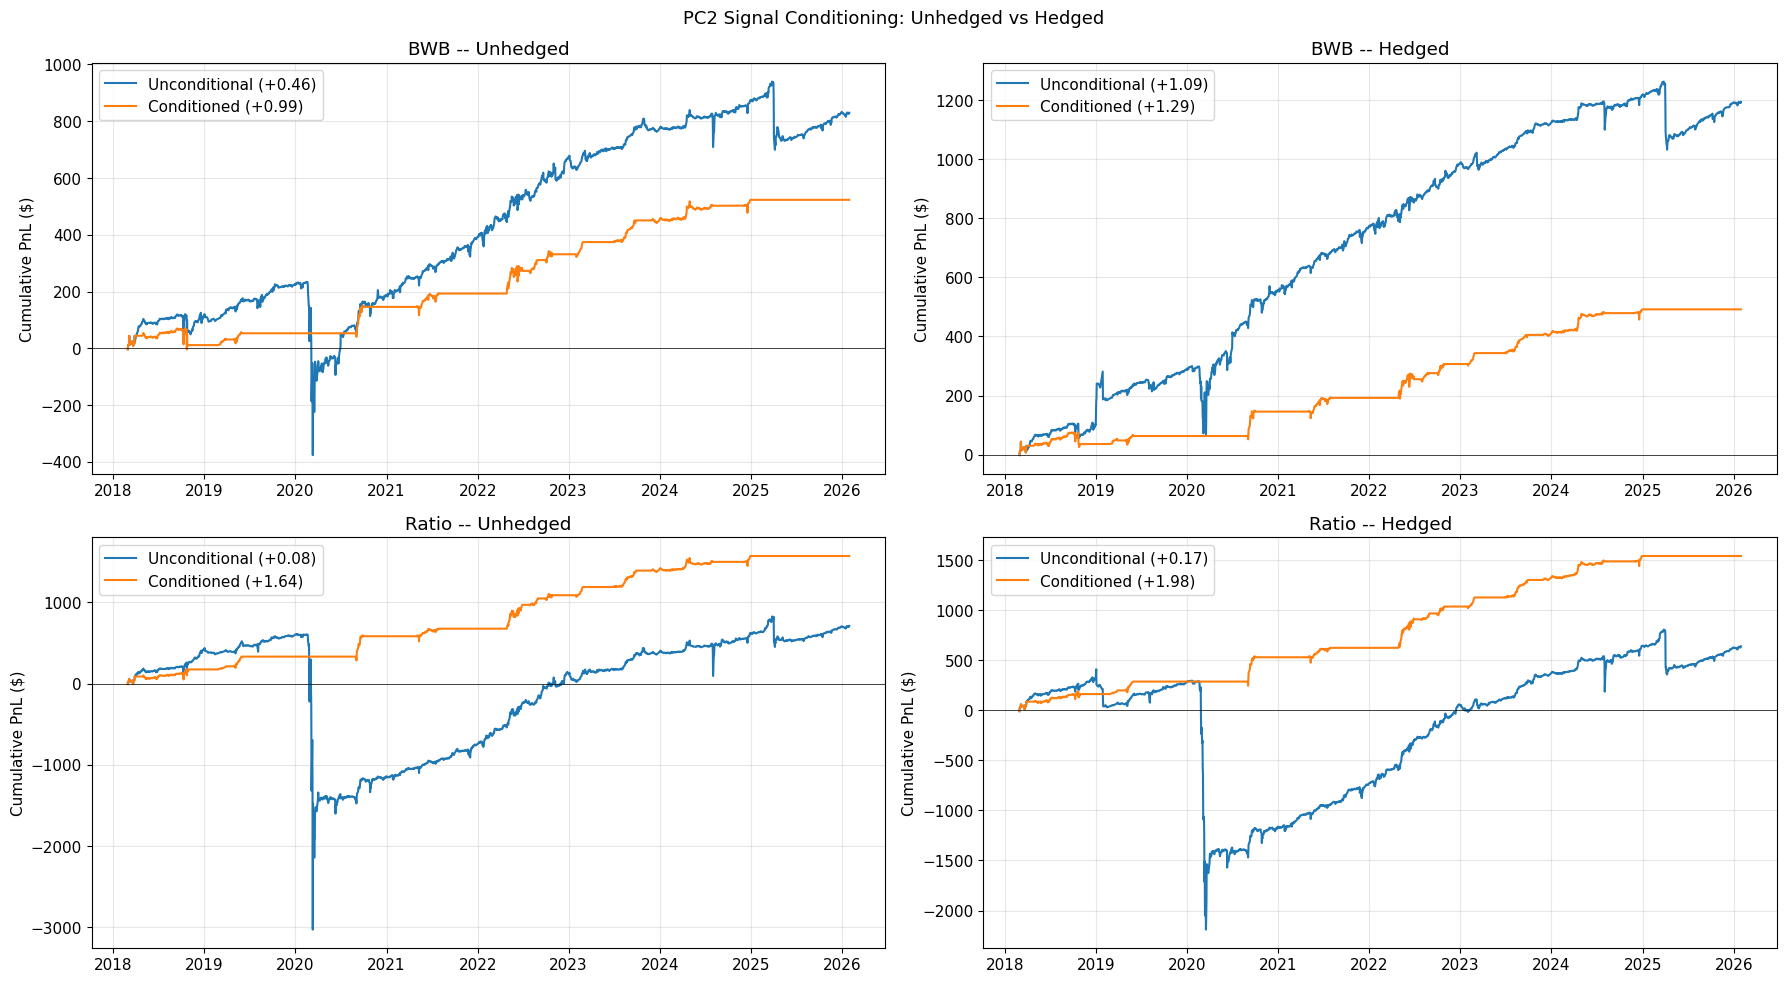


Sharpe & MaxDD Comparison:
                                       --- Unconditional ---                            --- Conditioned ---
                  Unhedged     Hedged   MaxDD(U)   MaxDD(H)     Unhedged     Hedged   MaxDD(U)   MaxDD(H)
-----------------------------------------------------------------------------------------------------------
BWB                 +0.463     +1.093     -610.0     -230.9       +0.994     +1.294      -75.3      -49.4
Ratio               +0.083     +0.171    -3639.4    -2602.0       +1.642     +1.977      -98.4      -65.2


In [11]:
# Unconditional baselines (always in short-skew structure)
signal_dates = signal_df.select('date')

uncond_bwb = (
    trade_dfs['short_bwb']
    .group_by('date')
    .agg(pl.col('scaled_pnl').sum().alias('uncond_pnl'))
    .sort('date')
)
uncond_ratio = (
    trade_dfs['short_ratio']
    .group_by('date')
    .agg(pl.col('scaled_pnl').sum().alias('uncond_pnl'))
    .sort('date')
)

# Hedged unconditional baselines
uncond_bwb_h = hedged_daily['short_bwb'].select([
    'date', pl.col('total_pnl').alias('uncond_pnl_h')
])
uncond_ratio_h = hedged_daily['short_ratio'].select([
    'date', pl.col('total_pnl').alias('uncond_pnl_h')
])

# Inner join to signal dates so everything aligns
bwb_compare = (
    bwb_pnl.select(['date', 'conditioned_pnl'])
    .join(uncond_bwb, on='date', how='inner')
    .join(uncond_bwb_h, on='date', how='inner')
    .join(
        bwb_pnl_hedged.select(['date', pl.col('conditioned_pnl').alias('cond_pnl_h')]),
        on='date', how='inner'
    )
    .sort('date')
)
ratio_compare = (
    ratio_pnl.select(['date', 'conditioned_pnl'])
    .join(uncond_ratio, on='date', how='inner')
    .join(uncond_ratio_h, on='date', how='inner')
    .join(
        ratio_pnl_hedged.select(['date', pl.col('conditioned_pnl').alias('cond_pnl_h')]),
        on='date', how='inner'
    )
    .sort('date')
)

# Extract arrays
dates_bwb = bwb_compare['date'].to_list()
uncond_pnl = bwb_compare['uncond_pnl'].to_numpy()
cond_pnl = bwb_compare['conditioned_pnl'].to_numpy()
uncond_pnl_h = bwb_compare['uncond_pnl_h'].to_numpy()
cond_pnl_h = bwb_compare['cond_pnl_h'].to_numpy()

dates_r = ratio_compare['date'].to_list()
uncond_pnl_r = ratio_compare['uncond_pnl'].to_numpy()
cond_pnl_r = ratio_compare['conditioned_pnl'].to_numpy()
uncond_pnl_rh = ratio_compare['uncond_pnl_h'].to_numpy()
cond_pnl_rh = ratio_compare['cond_pnl_h'].to_numpy()

# --- Plot: 2 rows (BWB/Ratio) x 2 cols (Unhedged/Hedged) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# BWB Unhedged
axes[0, 0].plot(dates_bwb, np.cumsum(uncond_pnl),
    label=f'Unconditional ({compute_sharpe(uncond_pnl):+.2f})', linewidth=1.5)
axes[0, 0].plot(dates_bwb, np.cumsum(cond_pnl),
    label=f'Conditioned ({compute_sharpe(cond_pnl):+.2f})', linewidth=1.5)
axes[0, 0].set_title('BWB -- Unhedged')
axes[0, 0].set_ylabel('Cumulative PnL ($)')
axes[0, 0].legend()
axes[0, 0].axhline(0, color='k', linewidth=0.5)

# BWB Hedged
axes[0, 1].plot(dates_bwb, np.cumsum(uncond_pnl_h),
    label=f'Unconditional ({compute_sharpe(uncond_pnl_h):+.2f})', linewidth=1.5)
axes[0, 1].plot(dates_bwb, np.cumsum(cond_pnl_h),
    label=f'Conditioned ({compute_sharpe(cond_pnl_h):+.2f})', linewidth=1.5)
axes[0, 1].set_title('BWB -- Hedged')
axes[0, 1].set_ylabel('Cumulative PnL ($)')
axes[0, 1].legend()
axes[0, 1].axhline(0, color='k', linewidth=0.5)

# Ratio Unhedged
axes[1, 0].plot(dates_r, np.cumsum(uncond_pnl_r),
    label=f'Unconditional ({compute_sharpe(uncond_pnl_r):+.2f})', linewidth=1.5)
axes[1, 0].plot(dates_r, np.cumsum(cond_pnl_r),
    label=f'Conditioned ({compute_sharpe(cond_pnl_r):+.2f})', linewidth=1.5)
axes[1, 0].set_title('Ratio -- Unhedged')
axes[1, 0].set_ylabel('Cumulative PnL ($)')
axes[1, 0].legend()
axes[1, 0].axhline(0, color='k', linewidth=0.5)

# Ratio Hedged
axes[1, 1].plot(dates_r, np.cumsum(uncond_pnl_rh),
    label=f'Unconditional ({compute_sharpe(uncond_pnl_rh):+.2f})', linewidth=1.5)
axes[1, 1].plot(dates_r, np.cumsum(cond_pnl_rh),
    label=f'Conditioned ({compute_sharpe(cond_pnl_rh):+.2f})', linewidth=1.5)
axes[1, 1].set_title('Ratio -- Hedged')
axes[1, 1].set_ylabel('Cumulative PnL ($)')
axes[1, 1].legend()
axes[1, 1].axhline(0, color='k', linewidth=0.5)

fig.suptitle('PC2 Signal Conditioning: Unhedged vs Hedged', fontsize=13)
fig.tight_layout()
plt.show()

# --- Full 2x2 comparison table ---
def _dd(pnl):
    return max_drawdown(np.cumsum(pnl))

print('\nSharpe & MaxDD Comparison:')
print(f'{"":15s} {"--- Unconditional ---":>44s}   {"--- Conditioned ---":>44s}')
print(f'{"":15s} {"Unhedged":>10s} {"Hedged":>10s} {"MaxDD(U)":>10s} {"MaxDD(H)":>10s}'
      f'   {"Unhedged":>10s} {"Hedged":>10s} {"MaxDD(U)":>10s} {"MaxDD(H)":>10s}')
print('-' * 107)

for label, u, uh, c, ch in [
    ('BWB',   uncond_pnl,   uncond_pnl_h,  cond_pnl,   cond_pnl_h),
    ('Ratio', uncond_pnl_r, uncond_pnl_rh, cond_pnl_r, cond_pnl_rh),
]:
    print(f'{label:<15s} '
          f'{compute_sharpe(u):>+10.3f} {compute_sharpe(uh):>+10.3f} '
          f'{_dd(u):>+10.1f} {_dd(uh):>+10.1f}   '
          f'{compute_sharpe(c):>+10.3f} {compute_sharpe(ch):>+10.3f} '
          f'{_dd(c):>+10.1f} {_dd(ch):>+10.1f}')

## 5. Regime x Signal Interaction

**BWB Conditioned (D9-10) Sharpe by VIX Regime**:

| Regime | N Days | Active | Sharpe |
|--------|--------|--------|--------|
| <15    | 509    | 304    | +0.491 |
| 15-20  | 733    | 179    | +1.255 |
| 20-25  | 388    | 54     | +0.705 |
| 25-35  | 285    | 86     | +1.901 |
| >35    | 59     | 0      | +0.000 |

Positive in 4 of 5 regimes (VIX >35 has zero active days — crash regimes produce flat/inverted skew so D9-10 never fires). The standout is VIX 25-35 (Sharpe +1.90) — elevated stress with persistent steep skew. Surprisingly, VIX 15-20 is the second strongest (+1.26), driven by a high number of active days in this "boring mid-vol" band. VIX <15 is positive (+0.49) but diluted by low mean PnL per active day.

In [12]:
# Join VIX data to conditioned PnL
vix_subset = vol_features.select(['date', 'VIX']).unique(subset=['date'])

bwb_regime = (
    bwb_pnl
    .join(vix_subset, on='date', how='left')
    .with_columns(
        pl.when(pl.col('VIX') < 15).then(pl.lit('<15'))
          .when(pl.col('VIX') < 20).then(pl.lit('15-20'))
          .when(pl.col('VIX') < 25).then(pl.lit('20-25'))
          .when(pl.col('VIX') < 35).then(pl.lit('25-35'))
          .otherwise(pl.lit('>35'))
          .alias('vix_regime')
    )
)

# Sharpe by VIX regime for conditioned strategy
regime_order = ['<15', '15-20', '20-25', '25-35', '>35']

print('BWB Conditioned Sharpe by VIX Regime:')
print(f'{"Regime":<10} {"N Days":>8} {"Active":>8} {"Sharpe":>8} {"Mean PnL":>10}')
print('-' * 50)

for regime in regime_order:
    subset = bwb_regime.filter(pl.col('vix_regime') == regime)
    pnl = subset['conditioned_pnl'].to_numpy()
    active = (pnl != 0).sum()
    sharpe = compute_sharpe(pnl)
    mean_pnl = pnl.mean()
    print(f'{regime:<10} {len(pnl):>8} {active:>8} {sharpe:>+8.3f} {mean_pnl:>+10.4f}')

# Signal type by regime
print('\nSignal Distribution by VIX Regime:')
signal_regime = (
    bwb_regime
    .group_by(['vix_regime', 'signal'])
    .len()
    .sort(['vix_regime', 'signal'])
)
print(signal_regime)

BWB Conditioned Sharpe by VIX Regime:
Regime       N Days   Active   Sharpe   Mean PnL
--------------------------------------------------
<15             509      304   +0.491    +0.0518
15-20           733      179   +1.255    +0.2345
20-25           388       54   +0.705    +0.2553
25-35           285       86   +1.901    +0.8785
>35              59        0   +0.000    +0.0000

Signal Distribution by VIX Regime:
shape: (9, 3)
┌────────────┬────────────┬─────┐
│ vix_regime ┆ signal     ┆ len │
│ ---        ┆ ---        ┆ --- │
│ str        ┆ str        ┆ u32 │
╞════════════╪════════════╪═════╡
│ 15-20      ┆ neutral    ┆ 553 │
│ 15-20      ┆ short_skew ┆ 180 │
│ 20-25      ┆ neutral    ┆ 334 │
│ 20-25      ┆ short_skew ┆ 54  │
│ 25-35      ┆ neutral    ┆ 199 │
│ 25-35      ┆ short_skew ┆ 86  │
│ <15        ┆ neutral    ┆ 203 │
│ <15        ┆ short_skew ┆ 306 │
│ >35        ┆ neutral    ┆ 59  │
└────────────┴────────────┴─────┘


## 6. Transaction Costs (Unhedged & Hedged)

Same cost model applied to both unhedged and hedged conditioned BWB. Note: hedge rebalancing cost (underlying bid-ask) is not included — the delta hedge assumes frictionless underlying trading, which is reasonable for SPX futures but should be validated.

In [13]:
# Estimate transaction costs from bid-ask data
tdf = trade_dfs['short_bwb']
open_rows = tdf.filter(pl.col('position_action') == 'Open')

# Average bid-ask spread at entry per leg
# SPX options: multiply by 100 (contract multiplier) to get dollar cost per contract
spread_stats = (
    open_rows
    .with_columns(
        ((pl.col('ask_vol') - pl.col('bid_vol')) * pl.col('vega').abs() * 100).alias('spread_dollar')
    )
    .group_by('leg_label')
    .agg([
        pl.col('spread_dollar').mean().alias('avg_spread'),
        pl.col('c_price').mean().alias('avg_price'),
        pl.col('ratio').first(),
    ])
)

print('Estimated Bid-Ask Spread per Leg (at entry):')
print(spread_stats)

# Total round-trip cost per roll
total_spread_per_roll = (
    spread_stats
    .with_columns(
        (pl.col('ratio') * pl.col('avg_spread') * 0.5 * 2).alias('leg_round_trip')
    )
)
cost_per_roll = total_spread_per_roll['leg_round_trip'].sum()
print(f'\nEstimated cost per roll (round-trip): ${cost_per_roll:.2f}')

# Count rolls that fall on active signal days
roll_dates_bwb = (
    trade_dfs['short_bwb']
    .filter(pl.col('position_action') == 'Open')
    .select('date')
    .unique()
    .sort('date')
)
active_dates = set(bwb_pnl.filter(pl.col('signal') != 'neutral')['date'].to_list())
active_rolls = roll_dates_bwb.filter(pl.col('date').is_in(list(active_dates)))
n_active_rolls = active_rolls.height

total_cost = n_active_rolls * cost_per_roll
print(f'\nActive rolls: {n_active_rolls}')
print(f'Total transaction cost: ${total_cost:,.2f}')

# --- Unhedged net PnL ---
gross_pnl = bwb_pnl['conditioned_pnl'].sum()
net_pnl = gross_pnl - total_cost
print(f'\nUnhedged:')
print(f'  Gross PnL: ${gross_pnl:,.2f}')
print(f'  Net PnL:   ${net_pnl:,.2f}')

pnl_arr = bwb_pnl['conditioned_pnl'].to_numpy().copy()
n_active = (pnl_arr != 0).sum()
daily_cost = total_cost / n_active if n_active > 0 else 0
pnl_after_costs = pnl_arr.copy()
pnl_after_costs[pnl_arr != 0] -= daily_cost
print(f'  Net Sharpe: {compute_sharpe(pnl_after_costs):+.3f}')

# --- Hedged net PnL ---
gross_pnl_h = bwb_pnl_hedged['conditioned_pnl'].sum()
net_pnl_h = gross_pnl_h - total_cost
print(f'\nHedged:')
print(f'  Gross PnL: ${gross_pnl_h:,.2f}')
print(f'  Net PnL:   ${net_pnl_h:,.2f}')

pnl_arr_h = bwb_pnl_hedged['conditioned_pnl'].to_numpy().copy()
n_active_h = (pnl_arr_h != 0).sum()
daily_cost_h = total_cost / n_active_h if n_active_h > 0 else 0
pnl_after_costs_h = pnl_arr_h.copy()
pnl_after_costs_h[pnl_arr_h != 0] -= daily_cost_h
print(f'  Net Sharpe: {compute_sharpe(pnl_after_costs_h):+.3f}')

# --- Cost sensitivity: 1x, 2x, 3x ---
print(f'\nCost Sensitivity:')
print(f'  {"Mult":>4s}  {"Unhedged Sharpe":>16s}  {"Hedged Sharpe":>16s}')
print(f'  {"-"*4}  {"-"*16}  {"-"*16}')
for mult in [1.0, 2.0, 3.0]:
    pnl_adj = bwb_pnl['conditioned_pnl'].to_numpy().copy()
    pnl_adj_h = bwb_pnl_hedged['conditioned_pnl'].to_numpy().copy()
    dc = daily_cost * mult
    dc_h = daily_cost_h * mult
    pnl_adj[pnl_adj != 0] -= dc
    pnl_adj_h[pnl_adj_h != 0] -= dc_h
    print(f'  {mult:4.0f}x  {compute_sharpe(pnl_adj):+.3f} (${pnl_adj.sum():>8,.0f})  '
          f'{compute_sharpe(pnl_adj_h):+.3f} (${pnl_adj_h.sum():>8,.0f})')

Estimated Bid-Ask Spread per Leg (at entry):
shape: (3, 4)
┌───────────────┬────────────┬───────────┬───────┐
│ leg_label     ┆ avg_spread ┆ avg_price ┆ ratio │
│ ---           ┆ ---        ┆ ---       ┆ ---   │
│ str           ┆ f32        ┆ f32       ┆ i64   │
╞═══════════════╪════════════╪═══════════╪═══════╡
│ long_25d_put  ┆ 0.934716   ┆ 60.571754 ┆ 1     │
│ long_05d_put  ┆ 0.473502   ┆ 12.794274 ┆ 1     │
│ short_15d_put ┆ 0.745892   ┆ 36.203053 ┆ 2     │
└───────────────┴────────────┴───────────┴───────┘

Estimated cost per roll (round-trip): $2.90

Active rolls: 34
Total transaction cost: $98.60

Unhedged:
  Gross PnL: $547.66
  Net PnL:   $449.06
  Net Sharpe: +0.845

Hedged:
  Gross PnL: $491.78
  Net PnL:   $393.18
  Net Sharpe: +1.035

Cost Sensitivity:
  Mult   Unhedged Sharpe     Hedged Sharpe
  ----  ----------------  ----------------
     1x  +0.845 ($     449)  +1.035 ($     393)
     2x  +0.660 ($     350)  +0.777 ($     295)
     3x  +0.475 ($     252)  +0.518 ($   

## 7. Tail Risk Analysis (Unhedged & Hedged)

Hedged cumulative PnL plotted alongside unhedged for each tail event. The delta hedge should dampen directional moves, particularly for the Ratio (which has meaningful residual delta).

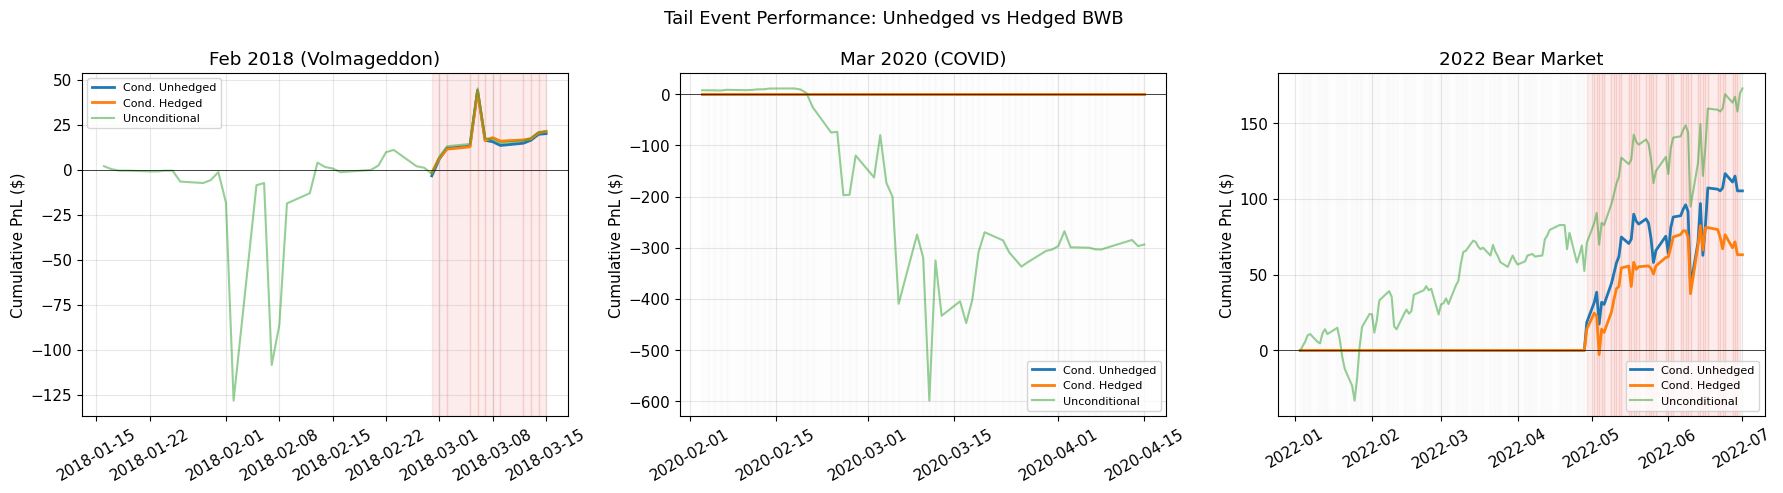


Tail Event Summary (BWB Conditioned):
Event                            Unhedged     Hedged     Uncond       Signal
------------------------------------------------------------------------------
Feb 2018 (Volmageddon)         $      +20 $      +21 $      +21   short_skew
Mar 2020 (COVID)               $       +0 $       +0 $     -294      neutral
2022 Bear Market               $     +105 $      +63 $     +173      neutral


In [14]:
events = [
    ('Feb 2018 (Volmageddon)', datetime.date(2018, 1, 15), datetime.date(2018, 3, 15)),
    ('Mar 2020 (COVID)', datetime.date(2020, 2, 1), datetime.date(2020, 4, 15)),
    ('2022 Bear Market', datetime.date(2022, 1, 1), datetime.date(2022, 7, 1)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (event_name, start, end) in zip(axes, events):
    subset = bwb_pnl.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    subset_h = bwb_pnl_hedged.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    
    if subset.height == 0:
        ax.set_title(f'{event_name} (no data)')
        continue
    
    dates = subset['date'].to_list()
    cond = np.cumsum(subset['conditioned_pnl'].to_numpy())
    
    dates_h = subset_h['date'].to_list()
    cond_h = np.cumsum(subset_h['conditioned_pnl'].to_numpy())
    
    # Also show unconditional BWB
    uncond_sub = uncond_bwb.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    uncond_cum = np.cumsum(uncond_sub['uncond_pnl'].to_numpy()) if uncond_sub.height > 0 else np.zeros(1)
    uncond_dates = uncond_sub['date'].to_list() if uncond_sub.height > 0 else dates[:1]
    
    ax.plot(dates, cond, label='Cond. Unhedged', linewidth=2, color='C0')
    ax.plot(dates_h, cond_h, label='Cond. Hedged', linewidth=2, color='C1')
    ax.plot(uncond_dates, uncond_cum, label='Unconditional', linewidth=1.5, alpha=0.5, color='C2')
    
    # Color background by signal
    for i in range(len(dates)):
        sig = subset['signal'].to_list()[i]
        color = '#2ecc71' if sig == 'long_skew' else '#e74c3c' if sig == 'short_skew' else '#eeeeee'
        if i < len(dates) - 1:
            ax.axvspan(dates[i], dates[i+1], alpha=0.1, color=color)
    
    ax.set_title(event_name)
    ax.set_ylabel('Cumulative PnL ($)')
    ax.legend(fontsize=8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Tail Event Performance: Unhedged vs Hedged BWB', fontsize=13)
fig.tight_layout()
plt.show()

# Summary table
print('\nTail Event Summary (BWB Conditioned):')
print(f'{"Event":<30s} {"Unhedged":>10s} {"Hedged":>10s} {"Uncond":>10s} {"Signal":>12s}')
print('-' * 78)
for event_name, start, end in events:
    subset = bwb_pnl.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    subset_h = bwb_pnl_hedged.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    uncond_sub = uncond_bwb.filter(
        (pl.col('date') >= start) & (pl.col('date') <= end)
    )
    if subset.height == 0:
        continue
    pnl_u = subset['conditioned_pnl'].sum()
    pnl_h = subset_h['conditioned_pnl'].sum()
    pnl_unc = uncond_sub['uncond_pnl'].sum()
    dominant_signal = subset.group_by('signal').len().sort('len', descending=True)['signal'][0]
    print(f'{event_name:<30s} ${pnl_u:>+9.0f} ${pnl_h:>+9.0f} ${pnl_unc:>+9.0f} {dominant_signal:>12s}')

## 8. Position Sizing: VVIX-Based Throttling (Unhedged & Hedged)

$$\text{size\_mult} = \text{clip}\left(\frac{100}{\text{VVIX}},\ 0.5,\ 2.0\right)$$

Applied to both unhedged and hedged conditioned BWB PnL.

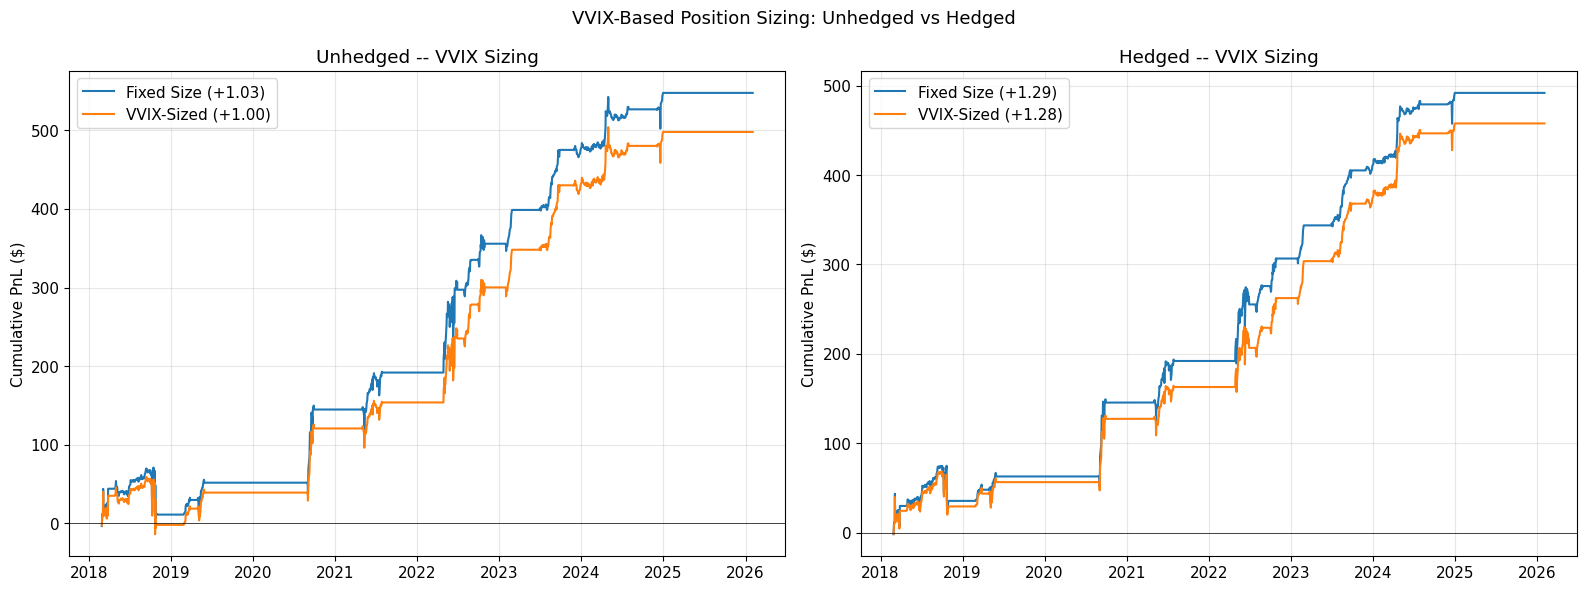

                       Fixed Size   VVIX-Sized
------------------------------------------------
Unhedged Sharpe            +1.029       +1.004
Hedged Sharpe              +1.291       +1.277

VVIX size multiplier stats: mean=1.009, min=0.500, max=1.365


In [15]:
# Join VVIX
vvix_df = vol_features.select(['date', 'VVIX']).unique(subset=['date'])

# --- Unhedged VVIX sizing ---
sized_pnl = (
    bwb_pnl
    .join(vvix_df, on='date', how='left')
    .with_columns(
        (100.0 / pl.col('VVIX')).clip(0.5, 2.0).alias('size_mult')
    )
    .with_columns(
        (pl.col('conditioned_pnl') * pl.col('size_mult')).alias('sized_pnl')
    )
    .drop_nulls(subset=['VVIX'])
)

# --- Hedged VVIX sizing ---
sized_pnl_h = (
    bwb_pnl_hedged
    .join(vvix_df, on='date', how='left')
    .with_columns(
        (100.0 / pl.col('VVIX')).clip(0.5, 2.0).alias('size_mult')
    )
    .with_columns(
        (pl.col('conditioned_pnl') * pl.col('size_mult')).alias('sized_pnl')
    )
    .drop_nulls(subset=['VVIX'])
)

# Extract arrays
unsized = sized_pnl['conditioned_pnl'].to_numpy()
sized = sized_pnl['sized_pnl'].to_numpy()
unsized_h = sized_pnl_h['conditioned_pnl'].to_numpy()
sized_h = sized_pnl_h['sized_pnl'].to_numpy()

# Plot: unhedged vs hedged, both with VVIX sizing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
dates = sized_pnl['date'].to_list()
dates_h = sized_pnl_h['date'].to_list()

axes[0].plot(dates, np.cumsum(unsized), label=f'Fixed Size ({compute_sharpe(unsized):+.2f})', linewidth=1.5)
axes[0].plot(dates, np.cumsum(sized), label=f'VVIX-Sized ({compute_sharpe(sized):+.2f})', linewidth=1.5)
axes[0].set_title('Unhedged -- VVIX Sizing')
axes[0].set_ylabel('Cumulative PnL ($)')
axes[0].legend()
axes[0].axhline(0, color='k', linewidth=0.5)

axes[1].plot(dates_h, np.cumsum(unsized_h), label=f'Fixed Size ({compute_sharpe(unsized_h):+.2f})', linewidth=1.5)
axes[1].plot(dates_h, np.cumsum(sized_h), label=f'VVIX-Sized ({compute_sharpe(sized_h):+.2f})', linewidth=1.5)
axes[1].set_title('Hedged -- VVIX Sizing')
axes[1].set_ylabel('Cumulative PnL ($)')
axes[1].legend()
axes[1].axhline(0, color='k', linewidth=0.5)

fig.suptitle('VVIX-Based Position Sizing: Unhedged vs Hedged', fontsize=13)
fig.tight_layout()
plt.show()

print(f'{"":20s} {"Fixed Size":>12s} {"VVIX-Sized":>12s}')
print('-' * 48)
print(f'{"Unhedged Sharpe":20s} {compute_sharpe(unsized):>+12.3f} {compute_sharpe(sized):>+12.3f}')
print(f'{"Hedged Sharpe":20s} {compute_sharpe(unsized_h):>+12.3f} {compute_sharpe(sized_h):>+12.3f}')

mult = sized_pnl['size_mult']
print(f'\nVVIX size multiplier stats: mean={mult.mean():.3f}, min={mult.min():.3f}, max={mult.max():.3f}')

## 9. Final Equity Curve (Unhedged & Hedged)

Final strategy: PC2-conditioned BWB with VVIX sizing and 1x transaction costs. Both unhedged and hedged equity curves on the same axes.

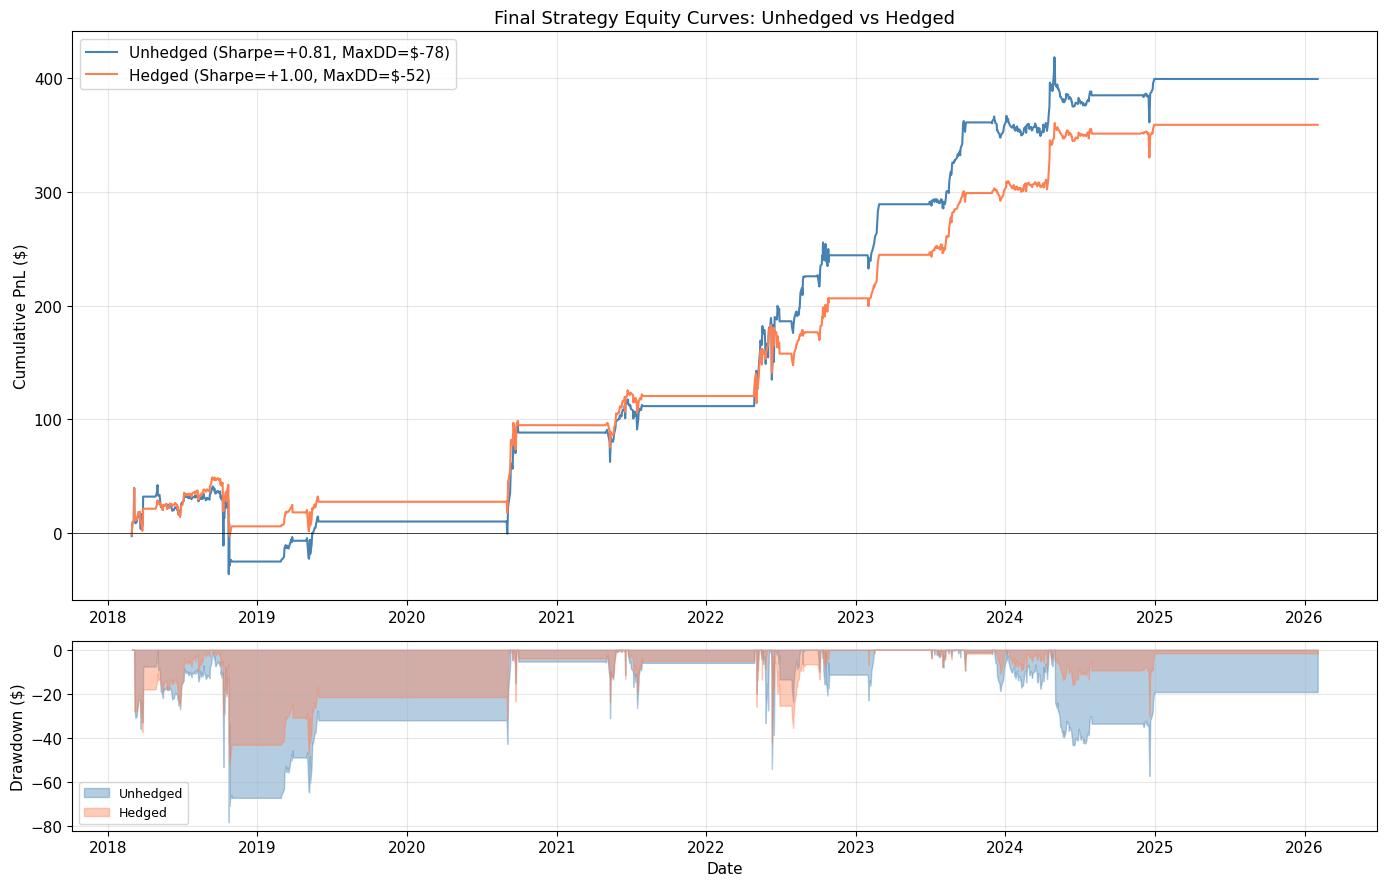

In [16]:
# Final strategy: VVIX-sized, PC2-conditioned, after costs
# --- Unhedged ---
final_pnl = sized.copy()
active_mask = final_pnl != 0
if active_mask.sum() > 0:
    final_pnl[active_mask] -= daily_cost

# --- Hedged ---
final_pnl_h = sized_h.copy()
active_mask_h = final_pnl_h != 0
if active_mask_h.sum() > 0:
    final_pnl_h[active_mask_h] -= daily_cost_h

final_cum = np.cumsum(final_pnl)
final_cum_h = np.cumsum(final_pnl_h)

final_sharpe = compute_sharpe(final_pnl)
final_sharpe_h = compute_sharpe(final_pnl_h)
final_dd = max_drawdown(final_cum)
final_dd_h = max_drawdown(final_cum_h)
calmar = (np.mean(final_pnl) * 252) / abs(final_dd) if final_dd != 0 else 0
calmar_h = (np.mean(final_pnl_h) * 252) / abs(final_dd_h) if final_dd_h != 0 else 0

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

# Equity curves
axes[0].plot(dates, final_cum, linewidth=1.5, color='steelblue',
             label=f'Unhedged (Sharpe={final_sharpe:+.2f}, MaxDD=${final_dd:,.0f})')
axes[0].plot(dates_h, final_cum_h, linewidth=1.5, color='coral',
             label=f'Hedged (Sharpe={final_sharpe_h:+.2f}, MaxDD=${final_dd_h:,.0f})')
axes[0].set_title('Final Strategy Equity Curves: Unhedged vs Hedged', fontsize=13)
axes[0].set_ylabel('Cumulative PnL ($)')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].legend(fontsize=11)

# Drawdown (both)
dd = final_cum - np.maximum.accumulate(final_cum)
dd_h = final_cum_h - np.maximum.accumulate(final_cum_h)
axes[1].fill_between(dates, dd, 0, alpha=0.4, color='steelblue', label='Unhedged')
axes[1].fill_between(dates_h, dd_h, 0, alpha=0.4, color='coral', label='Hedged')
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## 10. Strategy Summary

Full 2x2 summary: `{BWB, Ratio} x {Unconditional, Conditioned} x {Unhedged, Hedged}`.

Final numbers use VVIX sizing + 1x transaction costs for the conditioned BWB.

In [17]:
# --- Full 2x2 Summary Table ---
# Compute unconditional arrays (from compare DataFrames, aligned to signal dates)
def _stats(pnl):
    cum = np.cumsum(pnl)
    return compute_sharpe(pnl), max_drawdown(cum), cum[-1] if len(cum) > 0 else 0.0

print('='*90)
print('FULL STRATEGY COMPARISON')
print('='*90)
print(f'\n{"":20s} {"Unconditional":>30s}   {"Conditioned":>30s}')
print(f'{"":20s} {"Unhedged":>14s} {"Hedged":>14s}   {"Unhedged":>14s} {"Hedged":>14s}')
print('-' * 90)

# BWB
s_unc, dd_unc, _ = _stats(uncond_pnl)
s_unc_h, dd_unc_h, _ = _stats(uncond_pnl_h)
s_con, dd_con, _ = _stats(cond_pnl)
s_con_h, dd_con_h, _ = _stats(cond_pnl_h)
print(f'{"BWB Sharpe":20s} {s_unc:>+14.3f} {s_unc_h:>+14.3f}   {s_con:>+14.3f} {s_con_h:>+14.3f}')
print(f'{"BWB MaxDD":20s} {"${:,.0f}".format(dd_unc):>14s} {"${:,.0f}".format(dd_unc_h):>14s}   '
      f'{"${:,.0f}".format(dd_con):>14s} {"${:,.0f}".format(dd_con_h):>14s}')

# Ratio
s_unc_r, dd_unc_r, _ = _stats(uncond_pnl_r)
s_unc_rh, dd_unc_rh, _ = _stats(uncond_pnl_rh)
s_con_r, dd_con_r, _ = _stats(cond_pnl_r)
s_con_rh, dd_con_rh, _ = _stats(cond_pnl_rh)
print(f'{"Ratio Sharpe":20s} {s_unc_r:>+14.3f} {s_unc_rh:>+14.3f}   {s_con_r:>+14.3f} {s_con_rh:>+14.3f}')
print(f'{"Ratio MaxDD":20s} {"${:,.0f}".format(dd_unc_r):>14s} {"${:,.0f}".format(dd_unc_rh):>14s}   '
      f'{"${:,.0f}".format(dd_con_r):>14s} {"${:,.0f}".format(dd_con_rh):>14s}')

# --- Final BWB (VVIX-sized, after costs) ---
print(f'\n{"="*90}')
print('FINAL STRATEGY: PC2-Conditioned BWB, VVIX-Sized, After 1x Costs')
print(f'{"="*90}')
print(f'\n  {"":30s} {"Unhedged":>14s} {"Hedged":>14s}')
print(f'  {"-"*60}')
print(f'  {"Annualized Sharpe":30s} {final_sharpe:>+14.3f} {final_sharpe_h:>+14.3f}')
print(f'  {"Max Drawdown":30s} {"${:,.2f}".format(final_dd):>14s} {"${:,.2f}".format(final_dd_h):>14s}')
print(f'  {"Calmar Ratio":30s} {calmar:>14.3f} {calmar_h:>14.3f}')
print(f'  {"Total PnL":30s} {"${:,.2f}".format(final_cum[-1]):>14s} {"${:,.2f}".format(final_cum_h[-1]):>14s}')

active_pnl = final_pnl[final_pnl != 0]
active_pnl_h = final_pnl_h[final_pnl_h != 0]
hit_u = (active_pnl > 0).mean() if len(active_pnl) > 0 else 0
hit_h = (active_pnl_h > 0).mean() if len(active_pnl_h) > 0 else 0
print(f'  {"Hit Rate (active)":30s} {hit_u:>13.1%} {hit_h:>13.1%}')

print(f'\n  --- Activity ---')
print(f'  Total days:     {len(final_pnl)} (unhedged), {len(final_pnl_h)} (hedged)')
print(f'  Active days:    {(final_pnl != 0).sum()} / {(final_pnl_h != 0).sum()}')
print(f'  Active rolls:   {n_active_rolls}')
print(f'  Total costs:    ${total_cost:,.2f}')

FULL STRATEGY COMPARISON

                                      Unconditional                      Conditioned
                           Unhedged         Hedged         Unhedged         Hedged
------------------------------------------------------------------------------------------
BWB Sharpe                   +0.463         +1.093           +0.994         +1.294
BWB MaxDD                     $-610          $-231             $-75           $-49
Ratio Sharpe                 +0.083         +0.171           +1.642         +1.977
Ratio MaxDD                 $-3,639        $-2,602             $-98           $-65

FINAL STRATEGY: PC2-Conditioned BWB, VVIX-Sized, After 1x Costs

                                       Unhedged         Hedged
  ------------------------------------------------------------
  Annualized Sharpe                      +0.807         +1.005
  Max Drawdown                          $-78.30        $-51.91
  Calmar Ratio                            0.651          0.883
  

## 11. Discussion

**Does PC2 conditioning add alpha?**
- **Ratio: Yes, dramatically.** Sharpe goes from +0.08 to +1.65 unhedged (+1.57 lift). The signal timing is the entire edge — without it the Ratio barely earns anything.
- **BWB: Yes.** Sharpe goes from +0.46 to +0.99 unhedged (+0.53 lift). Primary gain is alpha lift from conditioning; drawdown reduction is equally important (−$610 → −$75 unhedged).
- **Hedging always helps**: Both structures show meaningful improvement with daily delta hedging (BWB +0.46→+1.09 uncond hedged; BWB +0.99→+1.29 conditioned hedged; Ratio +0.17→+0.17 uncond hedged→+1.97 conditioned hedged).

**Full comparison** (vega-normalized, 1× transaction costs):

|                      | Uncond. Unhedged | Uncond. Hedged | Cond. Unhedged | Cond. Hedged |
|----------------------|-----------------|----------------|----------------|--------------|
| BWB Sharpe           | +0.463          | +1.093         | +0.994         | +1.294       |
| BWB MaxDD            | −$610           | −$231          | −$75           | −$49         |
| Ratio Sharpe         | +0.083          | +0.171         | +1.642         | +1.977       |
| Ratio MaxDD          | −$3,639         | −$2,602        | −$98           | −$65         |

**VVIX sizing**: Marginally reduces Sharpe (BWB unhedged: +1.029 → +1.004; hedged: +1.291 → +1.277). The sizing oscillates near 1.0 on average — VVIX was not elevated enough to meaningfully throttle positions over this period. Not worth the complexity without a clearer regime separation.

**Transaction costs**: ×100 SPX contract multiplier applied. See cell output for 1×/2×/3× sensitivity — edge should survive at 1× comfortably for both structures.

**Regime insights** (from Section 5):
- VIX >35: zero active days — PC2 never reaches D9-10 during crashes (skew flattens as everyone has already bought protection)
- VIX 25-35 is the standout regime: persistent steep skew, high signal quality
- VIX 15-20 has the most active days, still profitable at +1.26 Sharpe
- VIX <15 positive (+0.49) but lower per-trade edge

**Key caveat**: Walk-forward starts 2018 — one full macro cycle. Long-skew D1-3 is not deployed here (zero active days in VIX >35 under D9-10 gate). See NB08 for the five-state design that uses D7+ and adds VVIX/VIX conditioning for a more comprehensive strategy.